# NDCube as a Data Container for Dynamic Spectra

In [1]:
import copy

import astropy.time
import astropy.units as u
import matplotlib.pyplot as plt
import ndcube
import numpy as np

from astropy.visualization import ImageNormalize, LogStretch, time_support
from ndcube.extra_coords.table_coord import QuantityTableCoordinate, TimeTableCoordinate
from radiospectra.net import attrs as ra
from radiospectra.spectrogram import Spectrogram
from sunpy.net import Fido, attrs as a

In [2]:
query = Fido.search(
    a.Time('2024-05-14', '2024-05-15 23:59'),
    a.Instrument.rfs
)

2026-05-25 02:42:34 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-05-25 02:42:34 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


In [3]:
query

Start Time,End Time,Instrument,Source,Provider,Wavelength
,,,,,kHz
Time,Time,str3,str3,str4,float64[2]
2024-05-14 00:00:00.000,2024-05-14 23:59:59.999,RFS,PSP,SPDF,10.0 .. 1700.0
2024-05-15 00:00:00.000,2024-05-15 23:59:59.999,RFS,PSP,SPDF,10.0 .. 1700.0
2024-05-14 00:00:00.000,2024-05-14 23:59:59.999,RFS,PSP,SPDF,1300.0 .. 19200.0
2024-05-15 00:00:00.000,2024-05-15 23:59:59.999,RFS,PSP,SPDF,1300.0 .. 19200.0


In [4]:
downloaded = Fido.fetch(query[0])  #doctest: +SKIP

Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

In [5]:
downloaded

['/home/willbarnes/sunpy/data/psp_fld_l2_rfs_lfr_20240514_v03.cdf', '/home/willbarnes/sunpy/data/psp_fld_l2_rfs_lfr_20240515_v03.cdf', '/home/willbarnes/sunpy/data/psp_fld_l2_rfs_hfr_20240514_v03.cdf', '/home/willbarnes/sunpy/data/psp_fld_l2_rfs_hfr_20240515_v03.cdf']

Use `radiospectra` to read in the data

In [6]:
specs = [Spectrogram(f) for f in downloaded]

## Building an `NDCube`

In [7]:
def build_ds_gwcs(time, frequency, ref_time=None):
    return (TimeTableCoordinate(time, reference_time=ref_time)
            & QuantityTableCoordinate(frequency, names='frequency', physical_types='phys.frequency')).wcs

In [8]:
build_ds_gwcs(astropy.time.Time('2020-01-01')+np.arange(0,24,1)*u.h, np.logspace(-2,2,100)*u.MHz)

<WCS(output_frame=CompositeFrame, input_frame=Frame-f776, forward_transform=Model: CompoundModel
Inputs: ('x0', 'x1')
Outputs: ('y0', 'y1')
Model set size: 1
Expression: [0] & [1]
Components: 
    [0]: <Tabular1D(points=(<Quantity [ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
               13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23.] pix>,), lookup_table=[    0.  3600.  7200. 10800. 14400. 18000. 21600. 25200. 28800. 32400.
     36000. 39600. 43200. 46800. 50400. 54000. 57600. 61200. 64800. 68400.
     72000. 75600. 79200. 82800.] s)>

    [1]: <Tabular1D(points=(<Quantity [ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
               13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
               26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
               39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
               52., 53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64.,
   

In [10]:
specs_cube = [ndcube.NDCube(s.data, build_ds_gwcs(s.times, s.frequencies, ref_time=None)) for s in specs]

## Plotting

In [11]:
plot_kw = {
    'norm': ImageNormalize(vmin=0, vmax=1e-12, stretch=LogStretch()),
    'interpolation':'none',
    'axes_units': ['MHz', 'h']
}

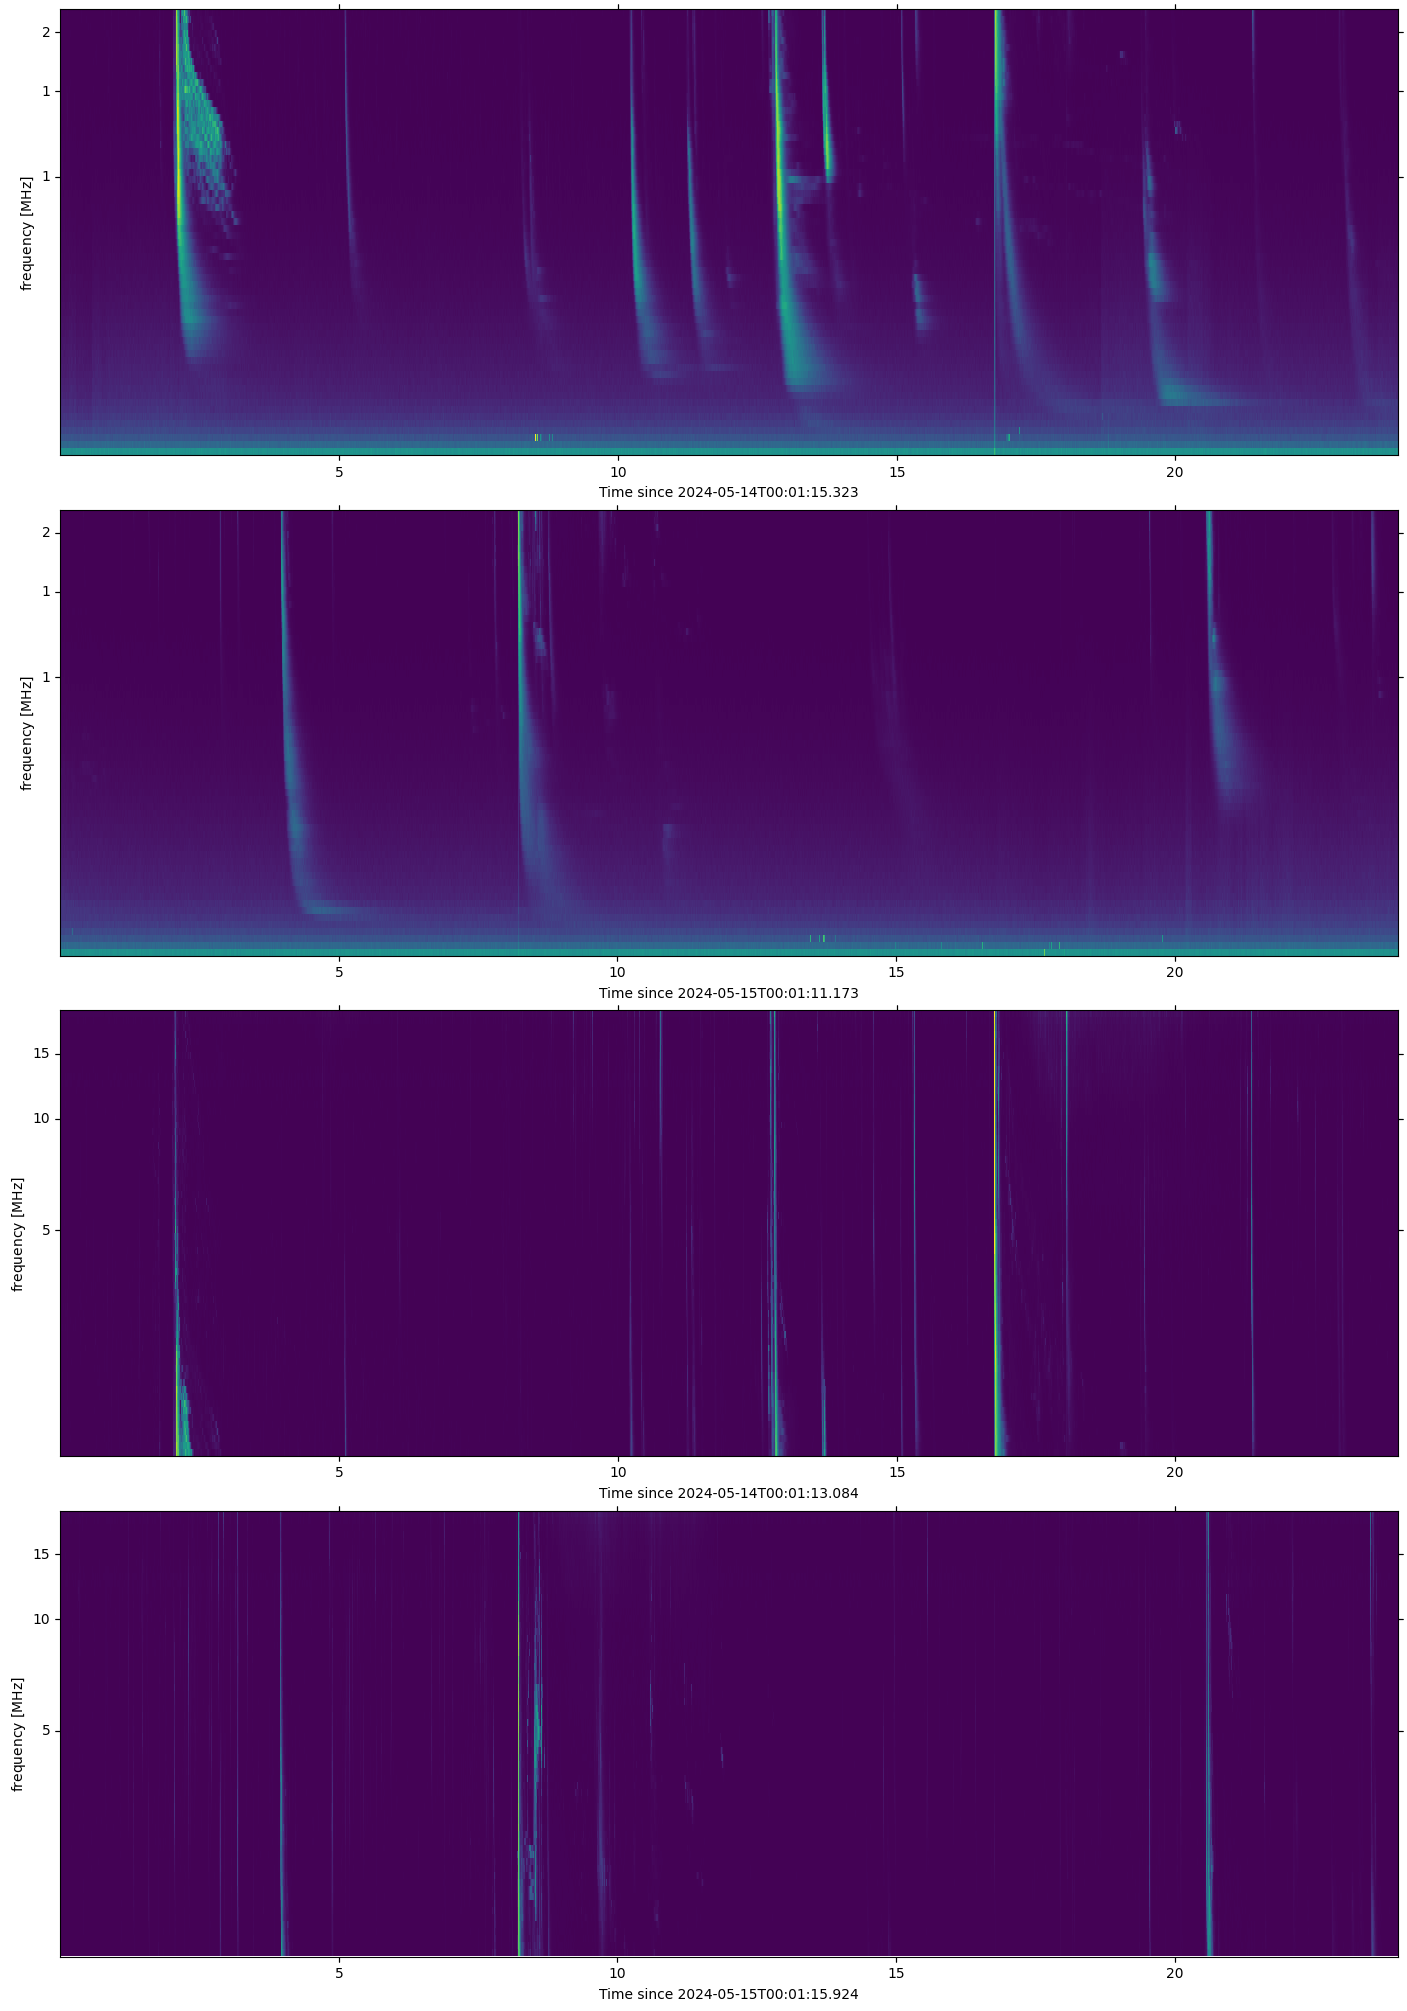

In [12]:
fig = plt.figure(figsize=(15,5*len(specs_cube)), layout='constrained')
for i,s in enumerate(specs_cube):
    ax = fig.add_subplot(len(specs_cube), 1, i+1, projection=s.wcs)
    s.plot(axes=ax, aspect=s.data.shape[1]/s.data.shape[0]/3,**plot_kw)
    ax.coords[0].set_axislabel(f'Time since {s.axis_world_coords('time')[0][0].isot}')

## Slicing

In [13]:
idx,_ = specs_cube[0].wcs.world_to_array_index(specs_cube[0].axis_world_coords('time')[0][0], 1*u.MHz)

In [14]:
spec_slice = specs_cube[0][int(idx),:]

<WCSAxes: ylabel='Data [V2 / Hz]'>

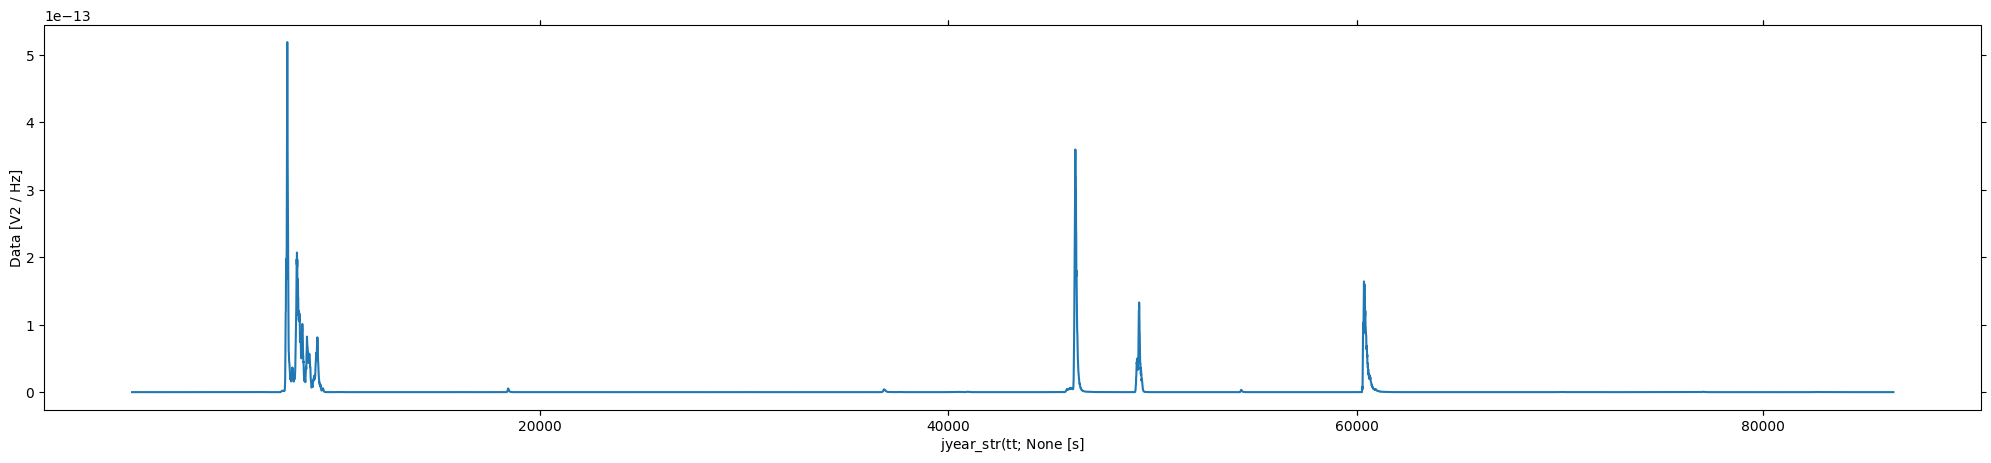

In [15]:
plt.figure(figsize=(25,5))
spec_slice.plot()

## Cropping

In [16]:
spec_crop = specs_cube[0].crop(
    (specs_cube[0].axis_world_coords('time')[0][900],None),
    (specs_cube[0].axis_world_coords('time')[0][1800],None),
)

<WCSAxes: >

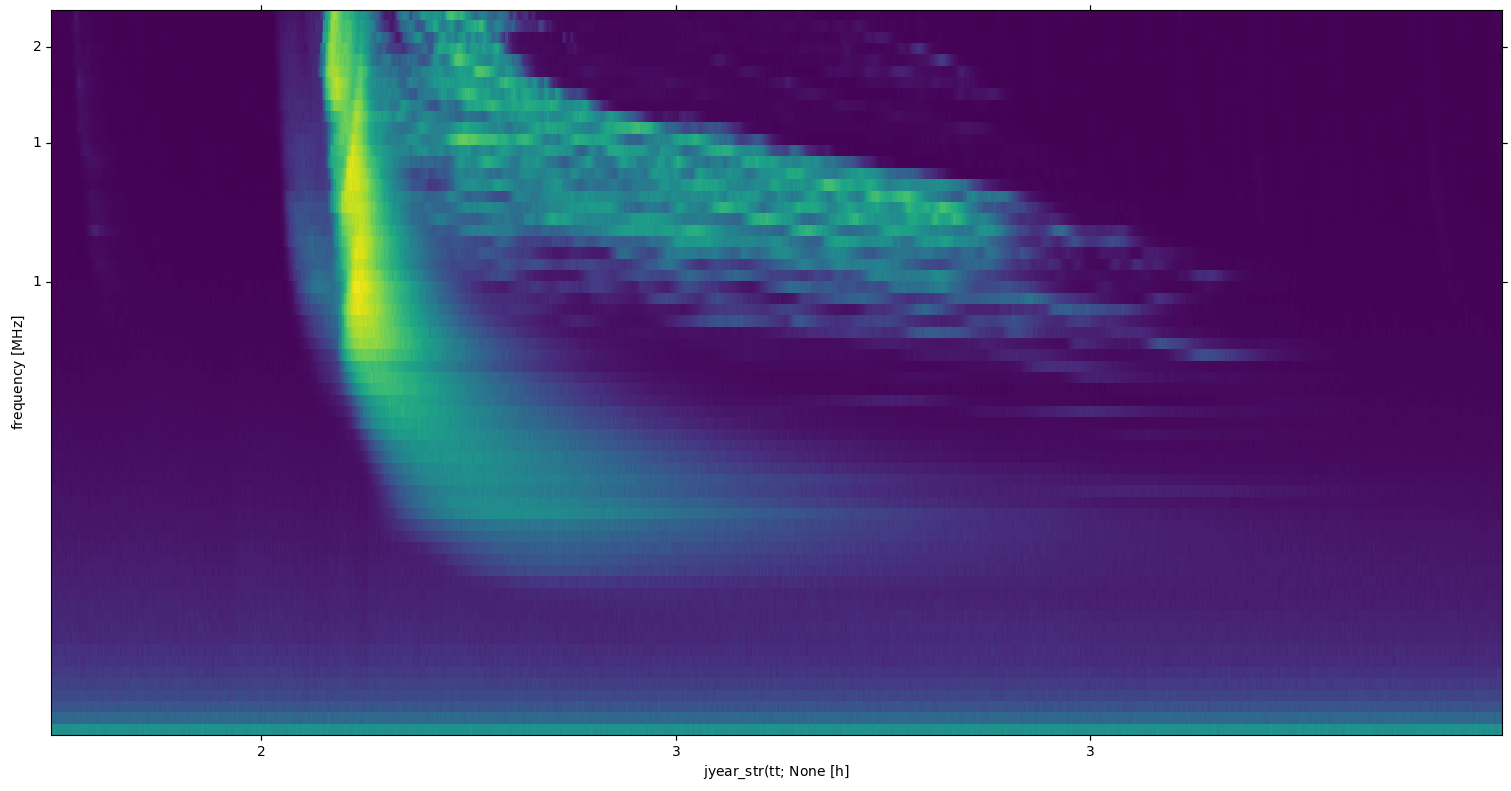

In [17]:
fig = plt.figure(figsize=(15,8), layout='constrained')
ax = fig.add_subplot(projection=spec_crop.wcs)
spec_crop.plot(axes=ax,aspect=spec_crop.data.shape[1]/spec_crop.data.shape[0]/2,**plot_kw)

## "Background" Subtraction

You can perform arithmetic operations on NDCubes with anything that (1) is broadcastable to the data array and (2) has the correct units (in the case of addition and subtraction).

In [20]:
spec_crop_no_bg = spec_crop - 1.2e-15*u.V**2/u.Hz
spec_crop_no_bg = spec_crop - 1.2e-15*u.V**2/u.Hz*np.ones(spec_crop.data.shape)
spec_crop_no_bg = spec_crop - spec_crop.quantity[:,:10].mean(axis=1)[:,np.newaxis]

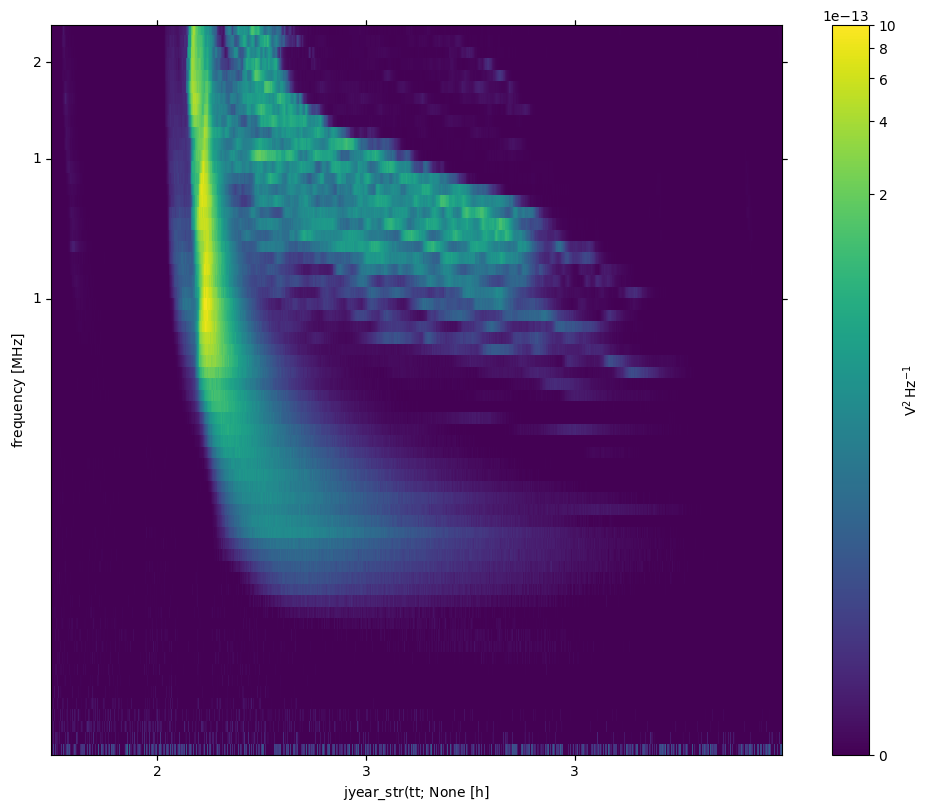

In [21]:
fig = plt.figure(figsize=(10,8), layout='constrained')
ax = fig.add_subplot(projection=spec_crop_no_bg.wcs)
spec_crop_no_bg.plot(axes=ax, aspect=spec_crop_no_bg.data.shape[1]/spec_crop_no_bg.data.shape[0],**plot_kw)
cbar = fig.colorbar(ax.get_images()[0], ax=ax)
cbar.set_label(spec_crop_no_bg.unit.to_string(format='latex_inline'))

## Masking

In [22]:
spec_crop_mask = copy.deepcopy(spec_crop)
spec_crop_mask.mask = spec_crop_mask.data < 1e-14

<WCSAxes: >

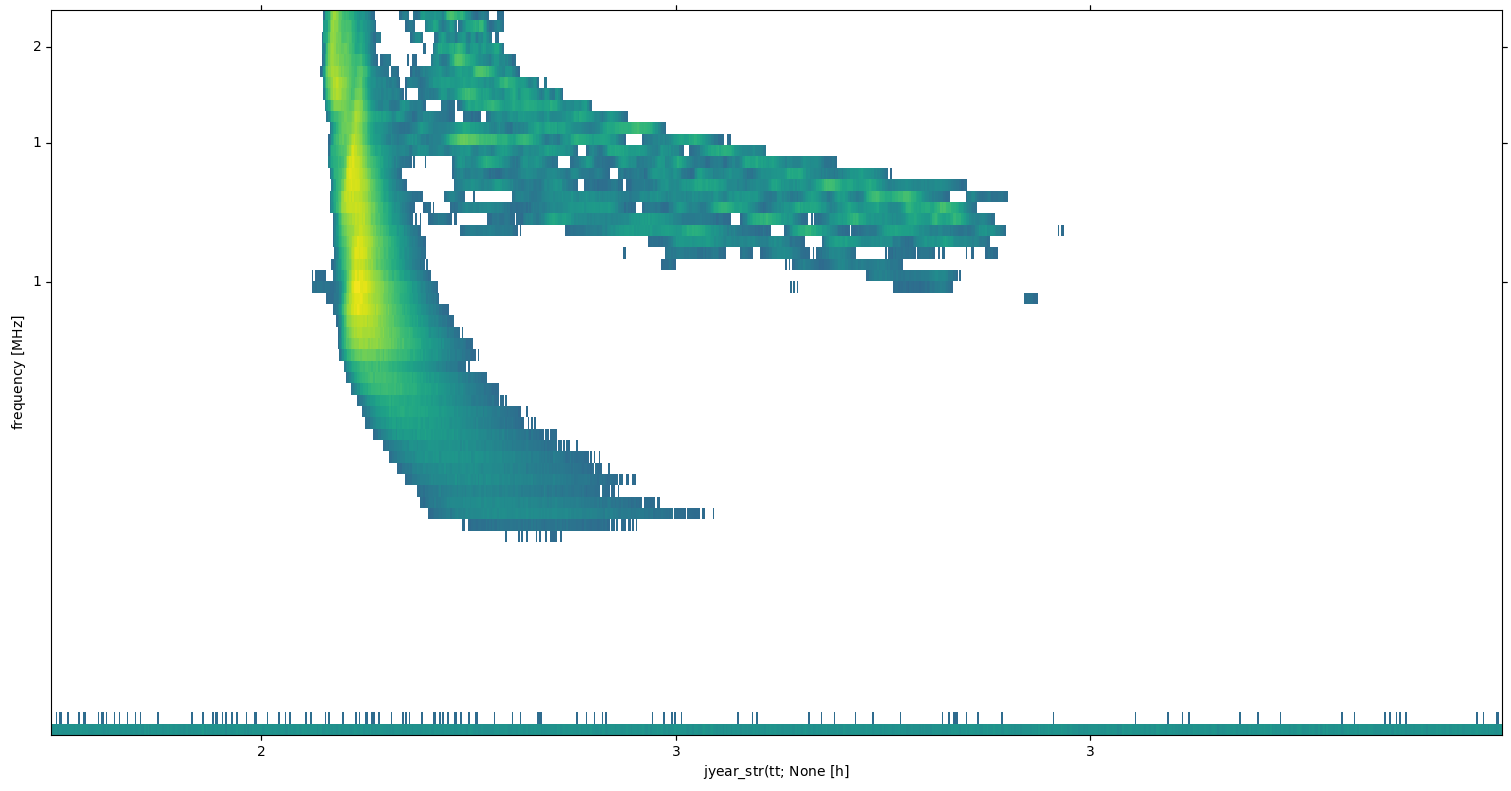

In [23]:
fig = plt.figure(figsize=(15,8), layout='constrained')
ax = fig.add_subplot(projection=spec_crop_mask.wcs)
spec_crop_mask.plot(axes=ax, aspect=spec_crop_mask.data.shape[1]/spec_crop_mask.data.shape[0]/2, **plot_kw)

## Extracting Intensities

Using the WCS, it is straightforward to find arbitrary paths through the data array in both pixel and coordinate space. The function below is adapted from code within `sunpy`, but in principle a similar function should live in `NDCube`.

In [28]:
idx_max = np.argmax(spec_crop.data, axis=0)
is_nz = np.where(idx_max>1)
idx_max = np.array([(i,j) for j,i in enumerate(idx_max)])[is_nz]
coord_max = spec_crop.wcs.pixel_to_world(idx_max[:,1], idx_max[:,0])

In [29]:
def pixelate_coord_path(smap, coord_path, bresenham=False):
    from sunpy.map.maputils import _bresenham, _intersected_pixels
    px, py = smap.wcs.world_to_pixel(*coord_path)
    if bresenham:
        px, py = np.rint(px).astype(int), np.rint(py).astype(int)
    pix = []
    for i in range(len(px) - 1):
        algorithm = _bresenham if bresenham else _intersected_pixels
        this_pix = algorithm(x1=px[i], y1=py[i], x2=px[i+1], y2=py[i+1])
        if i > 0:
            this_pix = this_pix[1:]
        pix.append(this_pix)
    pix = np.vstack(pix)
    pixel_coords = smap.wcs.pixel_to_world(pix[:, 0], pix[:, 1])
    return pixel_coords


def sample_at_coords(smap, coordinates):
    return u.Quantity(smap.data[smap.wcs.world_to_array_index(*coordinates)], smap.unit)

In [33]:
burst_coord = pixelate_coord_path(spec_crop, coord_max, bresenham=False)
burst_intensity = sample_at_coords(spec_crop, burst_coord)

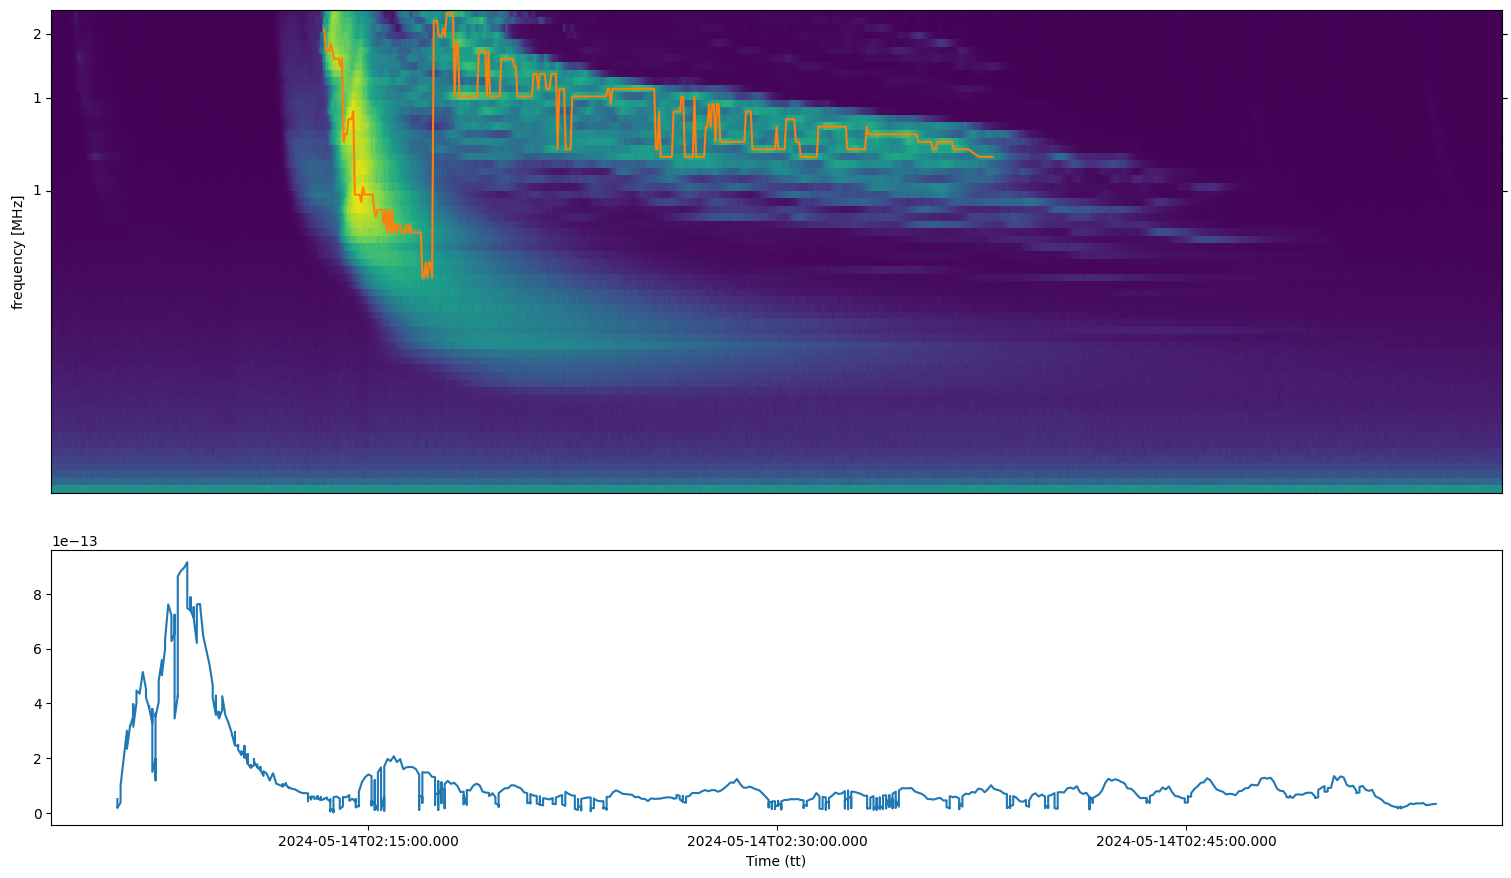

In [34]:
wh_ratio = 9/15
fig,axes = plt.subplot_mosaic(
    [['gram'],['gram'],['profile']],
    figsize=(15,15*wh_ratio),
    layout='constrained',
    per_subplot_kw={'gram':{'projection':spec_crop.wcs}}
)
spec_crop.plot(axes=axes['gram'], aspect=spec_crop.data.shape[1]/spec_crop.data.shape[0]/3,**plot_kw)
axes['gram'].coords[0].set_format_unit('h')
axes['gram'].coords[1].set_format_unit('MHz')
axes['gram'].plot(idx_max[:,1], idx_max[:,0], color='C1')
axes['gram'].label_outer()
axes['gram'].coords[0].set_ticks_visible(False)
axes['gram'].coords[0].set_ticklabel_visible(False)
with time_support(format='isot'):
    axes['profile'].plot(burst_coord[0], burst_intensity)

## Rebinning

In [35]:
spec_crop_rebin = spec_crop_mask.rebin((8,1), operation=np.sum, handle_mask=np.all)

<WCSAxes: >

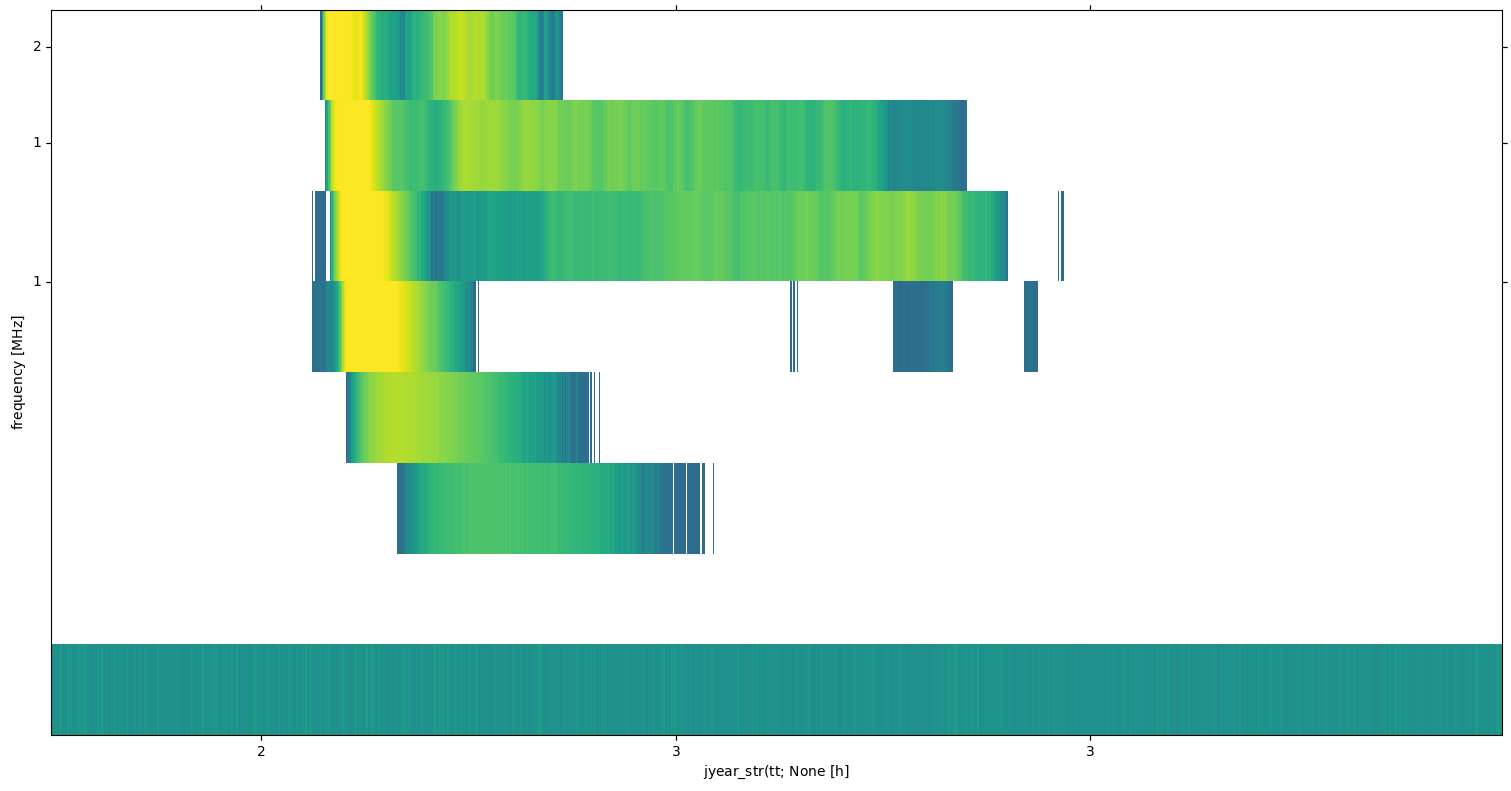

In [36]:
fig = plt.figure(figsize=(15,8), layout='constrained')
ax = fig.add_subplot(projection=spec_crop_rebin.wcs)
spec_crop_rebin.plot(axes=ax,aspect=spec_crop_rebin.data.shape[1]/spec_crop_rebin.data.shape[0]/2,**plot_kw)

## Combining with `reproject_to`

In [157]:
t0 = specs_cube[0].axis_world_coords('time')[0][0]
t1 = specs_cube[-1].axis_world_coords('time')[0][-1]
new_time = t0+np.arange(0,(t1-t0).to_value('h'),0.05)*u.h
new_freq = np.logspace(-2,1.4,120)*u.MHz
new_grid = build_ds_gwcs(new_time, new_freq)

In [158]:
new_shape = new_freq.shape + new_time.shape
new_array = np.zeros(new_shape)
for s in specs_cube:
    sr = s.reproject_to(new_grid, shape_out=new_shape)
    new_array += np.where(np.isnan(sr.data), 0, sr.data)
spec_repr = ndcube.NDCube(np.where(new_array==0, np.nan, new_array), new_grid)

<WCSAxes: >

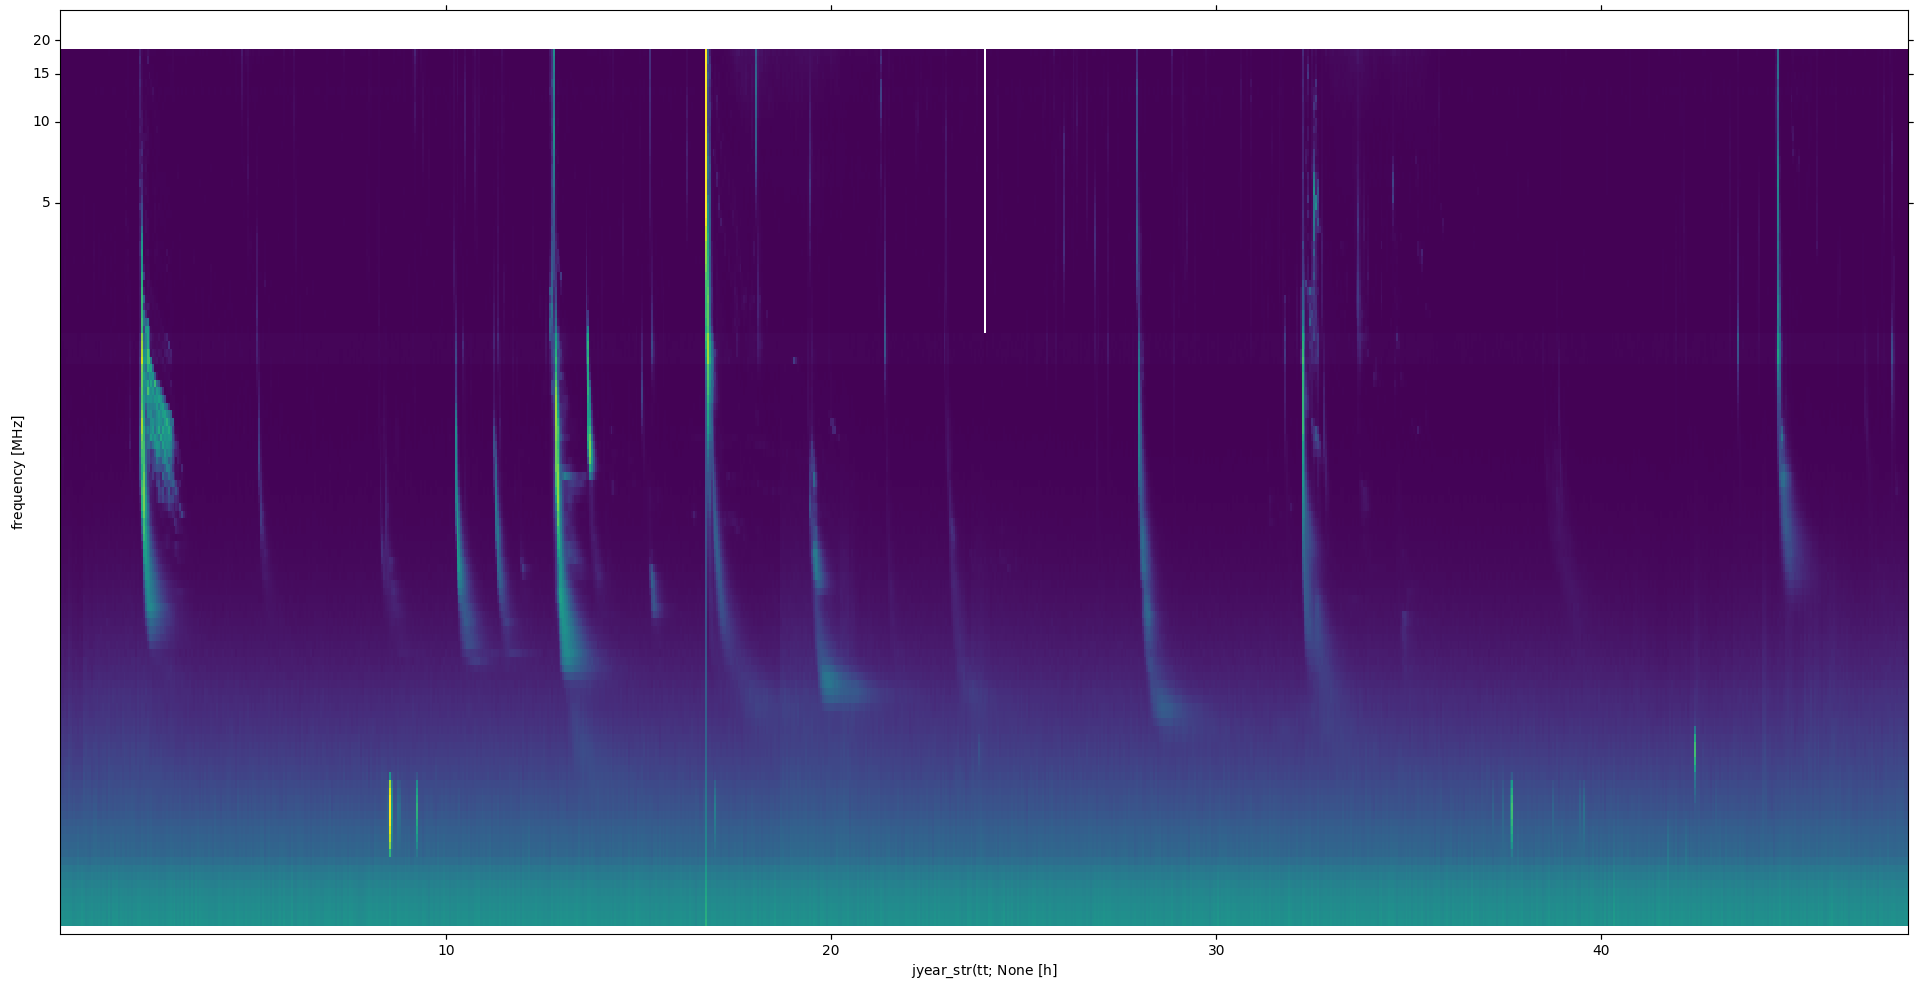

In [160]:
fig = plt.figure(figsize=(25,12))
ax = fig.add_subplot(projection=spec_repr.wcs)
spec_repr.plot(axes=ax,aspect=spec_repr.data.shape[1]/spec_repr.data.shape[0]/2,**plot_kw)